# Task V: Quantum Graph Neural Network (QGNN)


**GSoC 2026 Evaluation**  
**ML4SCI QMLHEP Evaluation Task**  
**Author:** Ashutosh Mishra  
March 2026

---

### Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | QGNN Architecture Design | Graph-to-quantum mapping and circuit motivation |
| 2 | Implementation | PennyLane circuit for a 5-node jet graph |
| 3 | Circuit Visualization | Draw the QGNN circuit |
| 4 | Execution & Output | Run the circuit and inspect expectation values |
| 5 | Discussion | Generalization, advantages, limitations, and HEP connection |

**Reference:** Verdon et al., "Quantum Graph Neural Networks" ([arXiv:1909.12264](https://arxiv.org/abs/1909.12264))

---

## 1. QGNN Architecture Design

### 1.1 Motivation

Classical Graph Neural Networks (GNNs) operate on irregular graph-structured data by passing messages between connected nodes. In high-energy physics, jet constituent particles form graphs: each particle is a node, and edges connect particles that are geometrically close in $(\eta, \phi)$ space.

A **Quantum Graph Neural Network** translates this graph structure into a quantum circuit, exploiting the correspondence between:

| Classical GNN Concept | Quantum Analog |
|----------------------|----------------|
| Node | Qubit |
| Node features | Single-qubit rotation angles |
| Edge / adjacency | Two-qubit entangling gate |
| Message passing | Quantum information propagation via entanglement |
| Neighbor aggregation | Entangling gates between connected qubits |
| Readout | Pauli expectation value measurement |

### 1.2 Graph-to-Quantum Mapping

Given a graph $G = (V, E)$ with $|V| = n$ nodes:

- **Each node $v_i$ maps to qubit $q_i$.** The node's feature value $x_i$ (e.g., particle $p_T$) is encoded via a rotation gate: $R_Y(x_i) |0\rangle$.
- **Each edge $(i, j) \in E$ maps to an entangling interaction** between qubits $q_i$ and $q_j$. I use a parameterized $ZZ$-interaction:

$$e^{-i \theta_{ij} Z_i Z_j}$$

which decomposes into the gate sequence: $\text{CNOT}(i,j) \to R_Z(2\theta_{ij}, j) \to \text{CNOT}(i,j)$.

This is the **key quantum advantage**: the entanglement structure *mirrors* the graph topology. Particles that are physically nearby in the detector become quantum-correlated in the circuit, while disconnected particles remain unentangled. The circuit respects the relational inductive bias of the data.

### 1.3 Message Passing Analogy

In a classical GNN, each layer performs:

$$h_i^{(l+1)} = \text{UPDATE}\left(h_i^{(l)},\; \text{AGGREGATE}\left(\{h_j^{(l)} : j \in \mathcal{N}(i)\}\right)\right)$$

The quantum analog proceeds as:

1. **AGGREGATE** $\to$ Entangling gates ($ZZ$-interactions) between connected qubits propagate quantum information along graph edges. After the entangling layer, each qubit's state depends on its neighbors; this is the quantum message.
2. **UPDATE** $\to$ Parameterized single-qubit rotations ($R_Y(\theta), R_Z(\phi)$) process the received quantum messages, analogous to the learned update function.

Stacking $L$ such layers allows information to propagate $L$ hops through the graph, exactly like $L$ layers of classical message passing.

### 1.4 Full Architecture

<img src="assets/qgnn_architecture.png" width="280"/>

### 1.5 Why Not a Fully-Connected Circuit?

A standard variational quantum circuit applies entangling gates between *all* qubit pairs (or in a fixed pattern like a chain). This ignores graph structure entirely. The QGNN's graph-aware entanglement has two benefits:

1. **Inductive bias**: Entanglement only where the data has relationships, reducing the hypothesis space
2. **Efficiency**: For sparse graphs, the QGNN uses $O(|E|)$ two-qubit gates per layer instead of $O(n^2)$, reducing circuit depth and noise on real hardware

---

## 2. Implementation

I implement the QGNN circuit in PennyLane for a 5-node example graph representing a simplified jet event.

In [10]:
# Install dependencies (uncomment if needed)
# !pip install pennylane numpy matplotlib

import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import matplotlib

np.random.seed(42)

print(f"PennyLane version: {qml.__version__}")

PennyLane version: 0.44.1


### 2.1 Define the Jet Graph

I construct a 5-node graph representing a toy jet event. Each node is a particle with a feature (e.g., transverse momentum $p_T$), and edges connect particles that are nearby in $(\eta, \phi)$ space.

<img src="assets/qgnn_jet_graph.png" width="200"/>

In [11]:
# Graph definition
n_nodes = 5
edges = [(0, 1), (0, 2), (0, 4), (1, 2), (2, 3), (3, 4)]
n_edges = len(edges)

# Node features: simulated particle pT values (normalized to [0, π] for rotation angles)
node_features = np.array([0.8, 1.2, 0.5, 1.5, 0.3]) * np.pi / 2

# Display
print(f"Nodes:    {n_nodes}")
print(f"Edges:    {edges}")
print(f"Features: {np.round(node_features, 3)}")
print(f"\nAdjacency list:")
for i in range(n_nodes):
    neighbors = [j for (a, b) in edges for j in ([b] if a == i else [a] if b == i else [])]
    print(f"  Node {i}: neighbors = {neighbors}")

Nodes:    5
Edges:    [(0, 1), (0, 2), (0, 4), (1, 2), (2, 3), (3, 4)]
Features: [1.257 1.885 0.785 2.356 0.471]

Adjacency list:
  Node 0: neighbors = [1, 2, 4]
  Node 1: neighbors = [0, 2]
  Node 2: neighbors = [0, 1, 3]
  Node 3: neighbors = [2, 4]
  Node 4: neighbors = [0, 3]


### 2.2 Visualize the Graph

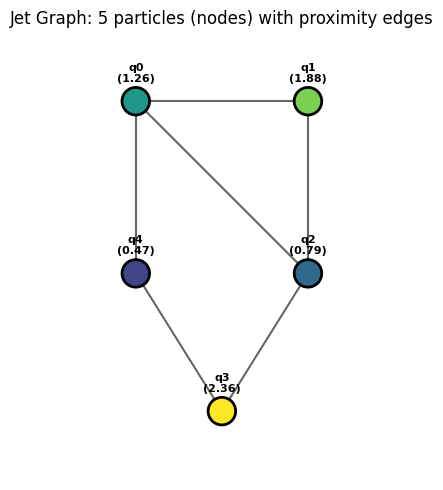

In [12]:
# Simple graph visualization using matplotlib
# Node positions for plotting
positions = {
    0: (0.0, 1.0),
    1: (1.0, 1.0),
    2: (1.0, 0.0),
    3: (0.5, -0.8),
    4: (0.0, 0.0),
}

fig, ax = plt.subplots(figsize=(5, 5))

# Draw edges
for (i, j) in edges:
    xi, yi = positions[i]
    xj, yj = positions[j]
    ax.plot([xi, xj], [yi, yj], 'k-', lw=1.5, alpha=0.6)

# Draw nodes
colors = plt.cm.viridis(node_features / (np.pi / 2 * 1.5))
for i, (x, y) in positions.items():
    circle = plt.Circle((x, y), 0.08, color=colors[i], ec='black', lw=2, zorder=5)
    ax.add_patch(circle)
    ax.annotate(f'q{i}\n({node_features[i]:.2f})', (x, y),
                ha='center', va='center', fontsize=8, fontweight='bold',
                xytext=(0, 20), textcoords='offset points')

ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-1.2, 1.4)
ax.set_aspect('equal')
ax.set_title('Jet Graph: 5 particles (nodes) with proximity edges', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

### 2.3 QGNN Circuit

The circuit has three components per layer:

1. **Data encoding** (first layer only): $R_Y(x_i)$ on each qubit $q_i$
2. **Edge entanglement**: For each edge $(i,j)$, apply a parameterized $ZZ$-interaction:
   $$e^{-i\theta_{ij} Z_i Z_j} = \text{CNOT}(i,j) \cdot R_Z(2\theta_{ij}, j) \cdot \text{CNOT}(i,j)$$
3. **Node update**: Trainable $R_Y(\alpha_i)$ and $R_Z(\beta_i)$ on each qubit

Steps 2-3 repeat for $L$ layers.

In [13]:
n_layers = 3
dev = qml.device("default.qubit", wires=n_nodes)


def zz_interaction(theta, wire_i, wire_j):
    """Parameterized ZZ-interaction: e^{-i * theta * Z_i Z_j}.
    
    Decomposition: CNOT(i,j) -> RZ(2*theta, j) -> CNOT(i,j)
    """
    qml.CNOT(wires=[wire_i, wire_j])
    qml.RZ(2 * theta, wires=wire_j)
    qml.CNOT(wires=[wire_i, wire_j])


@qml.qnode(dev)
def qgnn_circuit(node_features, edge_params, node_params):
    """Quantum Graph Neural Network circuit.
    
    Args:
        node_features: array of shape (n_nodes,) — input features for data encoding
        edge_params:   array of shape (n_layers, n_edges) — ZZ-interaction strengths
        node_params:   array of shape (n_layers, n_nodes, 2) — RY, RZ rotation angles
    
    Returns:
        Pauli-Z expectation values for all qubits
    """
    # --- Data Encoding Layer ---
    for i in range(n_nodes):
        qml.RY(node_features[i], wires=i)
    
    # --- Repeated QGNN Layers ---
    for layer in range(n_layers):
        
        # Edge entanglement: ZZ-interaction for each edge in the graph
        for e_idx, (i, j) in enumerate(edges):
            zz_interaction(edge_params[layer, e_idx], i, j)
        
        # Node update: parameterized single-qubit rotations
        for i in range(n_nodes):
            qml.RY(node_params[layer, i, 0], wires=i)
            qml.RZ(node_params[layer, i, 1], wires=i)
    
    # --- Measurement ---
    return [qml.expval(qml.PauliZ(i)) for i in range(n_nodes)]


print(f"Circuit parameters:")
print(f"  Edge params: ({n_layers}, {n_edges}) = {n_layers * n_edges} parameters")
print(f"  Node params: ({n_layers}, {n_nodes}, 2) = {n_layers * n_nodes * 2} parameters")
print(f"  Total trainable: {n_layers * n_edges + n_layers * n_nodes * 2} parameters")

Circuit parameters:
  Edge params: (3, 6) = 18 parameters
  Node params: (3, 5, 2) = 30 parameters
  Total trainable: 48 parameters


---

## 3. Circuit Visualization

### 3.1 Text Diagram

In [14]:
# Initialize parameters
np.random.seed(42)
edge_params = np.random.uniform(-np.pi, np.pi, size=(n_layers, n_edges))
node_params = np.random.uniform(-np.pi, np.pi, size=(n_layers, n_nodes, 2))

# Draw the circuit in text form
print("QGNN Circuit (5 nodes, 6 edges, 3 layers):")
print("=" * 80)
print(qml.draw(qgnn_circuit, max_length=120)(node_features, edge_params, node_params))

QGNN Circuit (5 nodes, 6 edges, 3 layers):
0: ──RY(1.26)─╭●────────────╭●─╭●───────────╭●─╭●───────────╭●──RY(-0.43)──RZ(-1.31)─────────────────────────╭● ···
1: ──RY(1.88)─╰X──RZ(-1.58)─╰X─│────────────│──│────────────│──╭●────────────────────╭●──RY(0.70)──RZ(-2.27)─╰X ···
2: ──RY(0.79)──────────────────╰X──RZ(5.66)─╰X─│────────────│──╰X──────────RZ(1.24)──╰X─╭●───────────────────╭● ···
3: ──RY(2.36)──────────────────────────────────│────────────│───────────────────────────╰X─────────RZ(-4.32)─╰X ···
4: ──RY(0.47)──────────────────────────────────╰X──RZ(2.92)─╰X───────────────────────────────────────────────── ···

0: ··· ────────────╭●─────────╭●────────────╭●────────╭●───────────╭●──RY(0.58)──RZ(-2.85)──────────────────────── ···
1: ··· ──RZ(-5.55)─╰X─────────│─────────────│─────────│────────────│──╭●───────────────────╭●──RY(0.68)──RZ(-2.07) ···
2: ··· ──RY(-1.31)──RZ(-0.84)─╰X──RZ(4.60)──╰X────────│────────────│──╰X─────────RZ(2.61)──╰X─╭●────────────────── ···
3: ··· ─╭●─────────

### 3.2 Matplotlib Visualization

/var/folders/xq/y8br4hqn3t93g5jccdygyqdh0000gn/T/ipykernel_2834/197141697.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


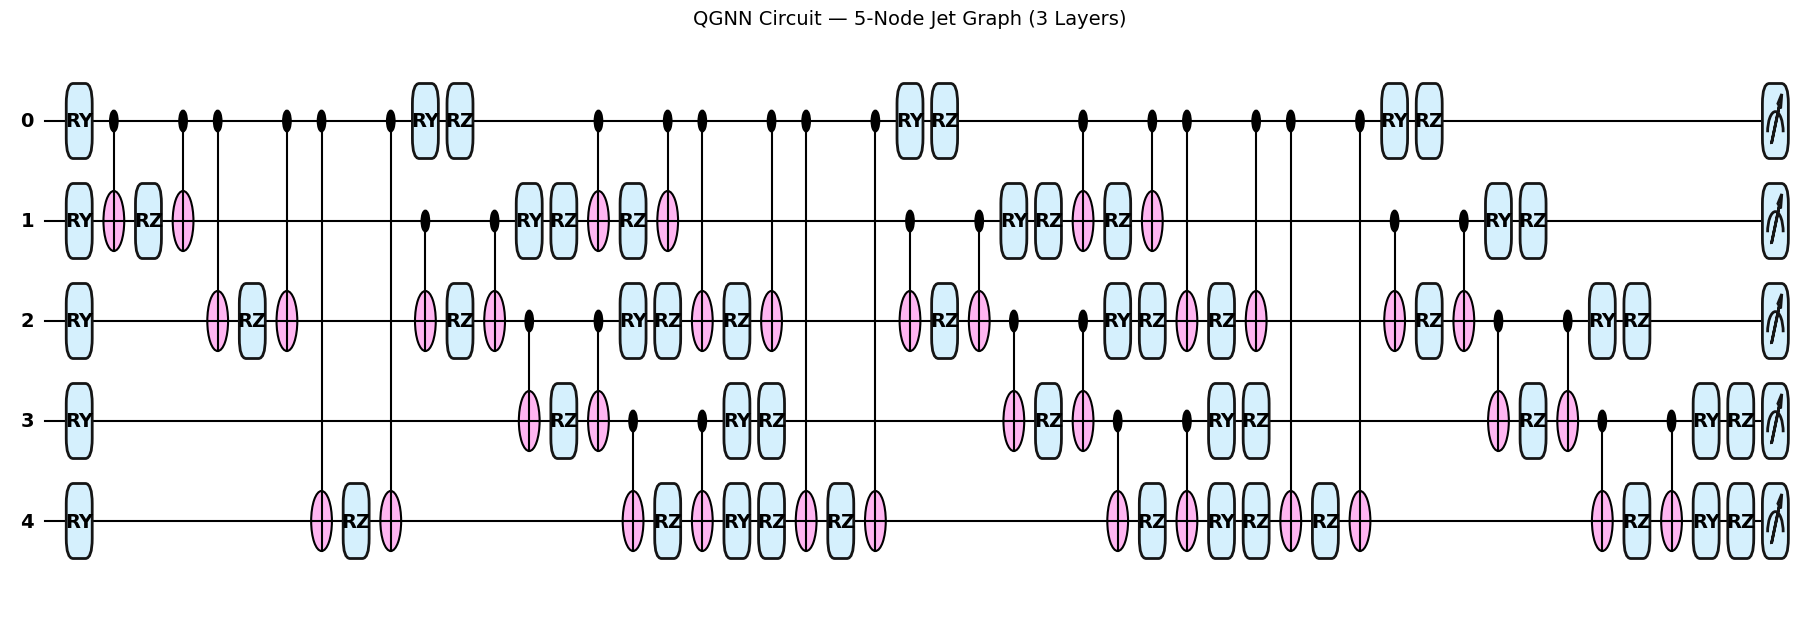

In [15]:
fig, ax = qml.draw_mpl(qgnn_circuit, style="pennylane")(node_features, edge_params, node_params)
fig.suptitle("QGNN Circuit — 5-Node Jet Graph (3 Layers)", fontsize=14, y=1.02)
fig.set_size_inches(18, 6)
plt.tight_layout()
plt.show()

### 3.3 Annotated Circuit Structure

Below is the logical structure of one QGNN layer for our 5-node graph. Each ZZ interaction decomposes as CNOT → RZ(2θ) → CNOT, applied only for edges present in the graph:

![QGNN Single Layer](assets/qgnn_single_layer.png)

---

## 4. Execution & Output

In [16]:
# Execute the circuit
result = qgnn_circuit(node_features, edge_params, node_params)

print("QGNN Output — Pauli-Z Expectation Values:")
print("=" * 50)
for i in range(n_nodes):
    neighbors = [j for (a, b) in edges for j in ([b] if a == i else [a] if b == i else [])]
    print(f"  Qubit {i} (feature={node_features[i]:.3f}, "
          f"neighbors={neighbors}): ⟨Z⟩ = {result[i]:+.4f}")

print(f"\nThese expectation values serve as updated node representations")
print(f"after quantum message passing — analogous to h_i^(L) in a classical GNN.")

QGNN Output — Pauli-Z Expectation Values:
  Qubit 0 (feature=1.257, neighbors=[1, 2, 4]): ⟨Z⟩ = +0.0026
  Qubit 1 (feature=1.885, neighbors=[0, 2]): ⟨Z⟩ = +0.5359
  Qubit 2 (feature=0.785, neighbors=[0, 1, 3]): ⟨Z⟩ = +0.1422
  Qubit 3 (feature=2.356, neighbors=[2, 4]): ⟨Z⟩ = -0.0199
  Qubit 4 (feature=0.471, neighbors=[0, 3]): ⟨Z⟩ = -0.2818

These expectation values serve as updated node representations
after quantum message passing — analogous to h_i^(L) in a classical GNN.


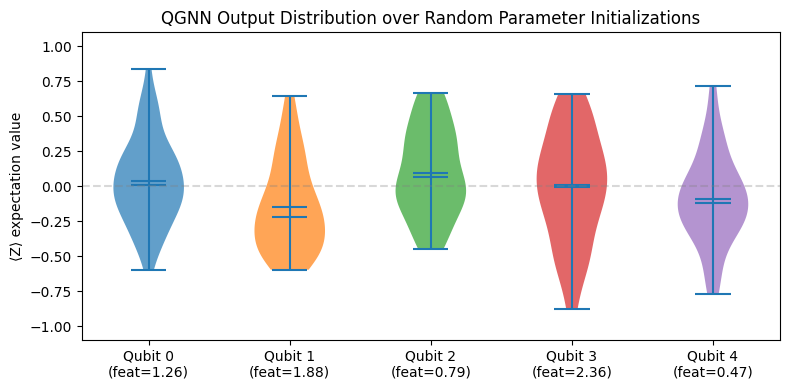

In [17]:
# Visualize how outputs change with different parameters (simulating training)
n_trials = 50
all_outputs = []

for trial in range(n_trials):
    ep = np.random.uniform(-np.pi, np.pi, size=(n_layers, n_edges))
    np_ = np.random.uniform(-np.pi, np.pi, size=(n_layers, n_nodes, 2))
    out = qgnn_circuit(node_features, ep, np_)
    all_outputs.append(out)

all_outputs = np.array(all_outputs)

fig, ax = plt.subplots(figsize=(8, 4))
parts = ax.violinplot(all_outputs, positions=range(n_nodes), showmeans=True, showmedians=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(plt.cm.tab10(i))
    pc.set_alpha(0.7)

ax.set_xticks(range(n_nodes))
ax.set_xticklabels([f'Qubit {i}\n(feat={node_features[i]:.2f})' for i in range(n_nodes)])
ax.set_ylabel('⟨Z⟩ expectation value')
ax.set_title('QGNN Output Distribution over Random Parameter Initializations', fontsize=12)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
ax.set_ylim(-1.1, 1.1)
plt.tight_layout()
plt.show()

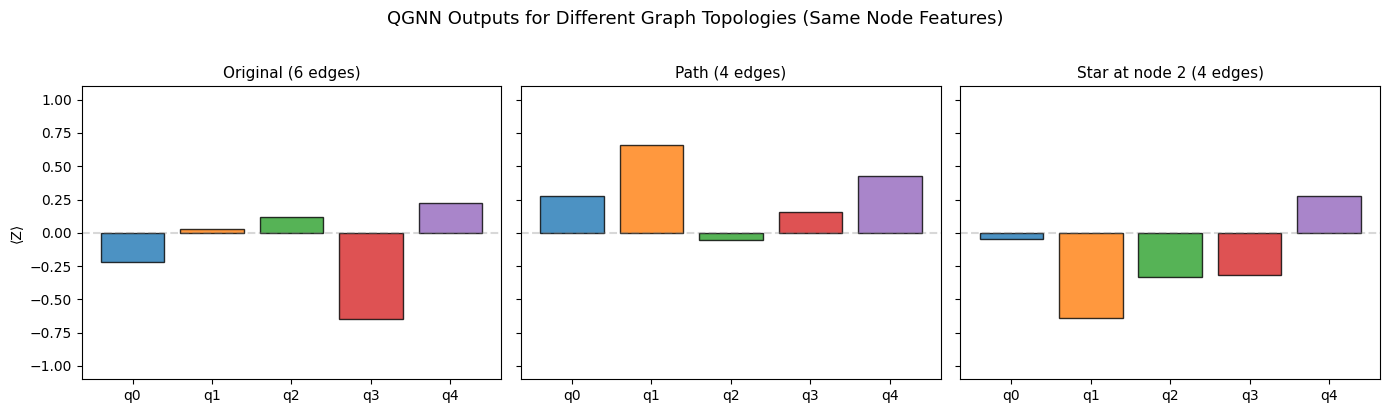

Different graph structures produce different outputs — the circuit is topology-aware.


In [18]:
# Demonstrate graph-structure sensitivity: compare outputs for different graphs
# using the same parameters

# Graph A: our original graph (6 edges)
edges_A = [(0, 1), (0, 2), (0, 4), (1, 2), (2, 3), (3, 4)]

# Graph B: a path graph (4 edges — sparser)
edges_B = [(0, 1), (1, 2), (2, 3), (3, 4)]

# Graph C: a star graph centered on node 2 (4 edges — different topology)
edges_C = [(2, 0), (2, 1), (2, 3), (2, 4)]


def make_qgnn(graph_edges, n_qubits, n_lay):
    """Create a QGNN QNode for a given graph."""
    dev = qml.device("default.qubit", wires=n_qubits)
    n_e = len(graph_edges)
    
    @qml.qnode(dev)
    def circuit(features, e_params, n_params):
        for i in range(n_qubits):
            qml.RY(features[i], wires=i)
        for layer in range(n_lay):
            for e_idx, (i, j) in enumerate(graph_edges):
                zz_interaction(e_params[layer, e_idx], i, j)
            for i in range(n_qubits):
                qml.RY(n_params[layer, i, 0], wires=i)
                qml.RZ(n_params[layer, i, 1], wires=i)
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    
    return circuit, n_e


# Same node features and node params, adapt edge params to graph size
np.random.seed(123)
shared_node_params = np.random.uniform(-np.pi, np.pi, size=(n_layers, n_nodes, 2))

graphs = {
    'Original (6 edges)': edges_A,
    'Path (4 edges)': edges_B,
    'Star at node 2 (4 edges)': edges_C,
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (name, g_edges) in zip(axes, graphs.items()):
    circ, ne = make_qgnn(g_edges, n_nodes, n_layers)
    ep = np.random.uniform(-np.pi, np.pi, size=(n_layers, ne))
    out = circ(node_features, ep, shared_node_params)
    
    colors = [plt.cm.tab10(i) for i in range(n_nodes)]
    bars = ax.bar(range(n_nodes), out, color=colors, edgecolor='black', alpha=0.8)
    ax.set_xticks(range(n_nodes))
    ax.set_xticklabels([f'q{i}' for i in range(n_nodes)])
    ax.set_title(name, fontsize=11)
    ax.set_ylabel('⟨Z⟩') if ax == axes[0] else None
    ax.set_ylim(-1.1, 1.1)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)

fig.suptitle('QGNN Outputs for Different Graph Topologies (Same Node Features)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Different graph structures produce different outputs — the circuit is topology-aware.")

---

## 5. Discussion

### 5.1 Generalization to Different Graph Structures

The QGNN circuit generalizes to arbitrary graphs:

- **Variable topology**: The entangling gate pattern is defined by the edge list, not hardcoded. Given any graph $G = (V, E)$, I simply apply $ZZ$-interactions for each edge in $E$. The same code handles dense, sparse, regular, or irregular graphs.
- **Variable size**: The number of qubits equals the number of nodes. A 10-particle jet uses 10 qubits; a 50-particle jet uses 50 qubits. No architectural changes are needed.
- **Weight sharing**: Following Verdon et al., edge parameters can be shared across all edges (a single $\theta$ per layer) or grouped by edge type. Weight sharing reduces parameters and improves generalization across different graph sizes.

### 5.2 Advantages

| Advantage | Explanation |
|-----------|-------------|
| **Graph-structured inductive bias** | Entanglement mirrors data topology, so the circuit "knows" which nodes are related |
| **Quantum superposition** | Each qubit exists in superposition, enabling the circuit to explore exponentially many feature combinations simultaneously |
| **Sparsity** | Sparse graphs yield shallow circuits with fewer two-qubit gates, reducing hardware noise |
| **Permutation equivariance** | Like classical GNNs, the QGNN is equivariant to node relabeling (when using shared edge weights) |
| **Potential exponential advantage** | The Hilbert space grows as $2^n$, potentially representing correlations that are intractable classically |

### 5.3 Limitations

| Limitation | Impact |
|-----------|--------|
| **Qubit count = node count** | Each particle requires one qubit. Real jets can have $O(100)$ constituents, far exceeding current NISQ device capacities (50–1000 noisy qubits) |
| **Barren plateaus** | As qubit count grows, gradients of random circuits vanish exponentially, making training difficult without careful initialization |
| **Limited feature encoding** | A single $R_Y$ gate per node encodes only one scalar feature. Multi-feature encoding requires either more qubits per node or sequential re-encoding |
| **Circuit depth** | For dense graphs, the number of $ZZ$-interactions per layer scales as $O(|E|)$, increasing depth and decoherence |
| **Classical simulation cost** | Simulating $n$-qubit circuits classically costs $O(2^n)$, limiting development and hyperparameter search |

### 5.4 Connection to Jet Tagging in HEP

In jet classification (quark vs. gluon, top tagging, etc.), the QGNN maps onto the physics:

| Physics | QGNN |
|---------|------|
| Jet constituent particle | Node / qubit |
| Particle $p_T$, $\eta$, $\phi$, mass | Node features → $R_Y$ encoding |
| Nearby particles ($\Delta R < R_0$) | Edge → $ZZ$-interaction |
| Jet substructure (prongs, splittings) | Emerges from graph topology |
| Classification label | Classical readout from $\langle Z \rangle$ values |

**Practical workflow:**
1. Cluster jet constituents and build a $k$-nearest-neighbor or $\Delta R$-based graph
2. Encode particle features into qubit rotations
3. Run $L$ layers of QGNN (edge entanglement + node updates)
4. Pool $\langle Z \rangle$ values (e.g., mean or attention-weighted sum) into a global jet representation
5. Pass through a classical output layer for classification

This is a hybrid quantum-classical pipeline where the QGNN acts as a learned feature extractor that respects the jet's geometric structure.

### 5.5 Outlook

- **Near-term**: QGNNs with $O(10)$ qubits are feasible on current hardware. Pre-selecting the top-$k$ hardest constituents keeps qubit counts manageable.
- **Fault-tolerant era**: With error-corrected qubits, QGNNs could process full jets ($O(100)$ particles) and potentially capture quantum correlations inaccessible to classical GNNs.
- **Hybrid architectures**: Combining classical GNN layers (for coarse feature extraction) with a QGNN layer (for fine-grained quantum correlations) may offer the best of both worlds.

**Reference:** Verdon, G. et al. "Quantum Graph Neural Networks." *arXiv:1909.12264* (2019).